# Outline

# Purpose: 
- ## This notebook is meant to automate the analysis of single cell RNA-seq data.

## Setup
- Download and install necessary data files for the analysis
    - These files include a whitelist of barcodes, a human refrence genome (chr5), a gtf file with transcript info, and single cell FASTQ RNA->DNA sequence files from 2 .

### The Data
This notebook makes use of 2 fastq files containing single cell RNA-seq data. The R1 reads file contains cell barcodes and unique molecular identifiers (UMIs), while the R2 reads file contains the actual DNA sequences formed from RNA in sample wells. A whitelist of known barcodes is also provided to filter out any potential sequencing errors in the cell barcodes, and a gtf file is provided to map the DNA sequences to known genes, along with a reference genome file for alignment (containing genes from chromosome 5 of the human genome only). The length of reads in R2 is 90 basepairs, while len(barcodes+UMI) = 28 basepairs. It is of note that there are around 6 million whitelisted barcodes (allowing for small sequencing errors) in the provided whitelist file, while there are aroudn 100,000 reads in the R2/R1 fastq file.

Download statements:

    sudo apt update
    sudo apt install fastqc
    conda install -c bioconda alevin-fry



In [107]:
%%bash
# Create directories for organizing the data we're receiving
rm -rf data

mkdir data data/reads data/fastqc_analysis data/ref_genome data/barcodes
# The set of reads and reference genome chromosome (chromosome 10 of the hu)

tar -xzvf toy_read_ref_set.tar.gz 
mv toy_ref_read/toy_human_ref/fasta/ data/ref_genome
mv toy_ref_read/toy_human_ref/genes/ data/ref_genome
mv toy_ref_read/toy_read_fastq/* data/reads
rm -rf toy_ref_read

# The whitelist barcodes for the samples
wget https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz -O 3M-february-2018.txt.gz
gunzip 3M-february-2018.txt.gz
mv 3M-february-2018.txt data/barcodes





toy_ref_read/
toy_ref_read/toy_human_ref/
toy_ref_read/toy_human_ref/fasta/
toy_ref_read/toy_human_ref/fasta/genome.fa


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


toy_ref_read/toy_human_ref/genes/
toy_ref_read/toy_human_ref/genes/genes.gtf
toy_ref_read/toy_read_fastq/
toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
toy_ref_read/toy_read_fastq/selected_R2_reads.fastq


--2025-11-20 23:25:54--  https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/f0t1h/3M-february-2018/refs/heads/master/3M-february-2018.txt.gz [following]
--2025-11-20 23:25:55--  https://raw.githubusercontent.com/f0t1h/3M-february-2018/refs/heads/master/3M-february-2018.txt.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18350152 (18M) [application/octet-stream]
Saving to: ‘3M-february-2018.txt.gz’

     0K .......... .......... .......... .......... ..........  0%  922K 19s
    50K .......... .......... .....

### General sequence analysis
Prior to actually aligning the reads to a reference genome it's good to get a sense of the quality of the reads. Each read comes with a quality score (as they are in the FASTQ format). This is accomplished using FastQC, which provides an HTML based graphical report of various quality metrics for the reads. A text based summary is also provided byy the tool. The reports are located in data/fastqc_reports.

In [108]:
%%bash
fastqc data/reads/*.fastq -o data/fastqc_analysis
for f in data/fastqc_analysis/*.zip; do
    unzip "$f" -d data/fastqc_analysis/
done


null
null


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Started analysis of selected_R1_reads.fastq
Approx 5% complete for selected_R1_reads.fastq
Approx 10% complete for selected_R1_reads.fastq
Approx 15% complete for selected_R1_reads.fastq
Approx 20% complete for selected_R1_reads.fastq
Approx 25% complete for selected_R1_reads.fastq
Approx 30% complete for selected_R1_reads.fastq
Approx 35% complete for selected_R1_reads.fastq
Approx 40% complete for selected_R1_reads.fastq
Approx 45% complete for selected_R1_reads.fastq
Approx 50% complete for selected_R1_reads.fastq
Approx 55% complete for selected_R1_reads.fastq
Approx 60% complete for selected_R1_reads.fastq
Approx 65% complete for selected_R1_reads.fastq
Approx 70% complete for selected_R1_reads.fastq
Approx 75% complete for selected_R1_reads.fastq
Approx 80% complete for selected_R1_reads.fastq
Approx 85% complete for selected_R1_reads.fastq
Approx 90% complete for sel

Analysis complete for selected_R1_reads.fastq


Started analysis of selected_R2_reads.fastq
Approx 5% complete for selected_R2_reads.fastq
Approx 10% complete for selected_R2_reads.fastq
Approx 15% complete for selected_R2_reads.fastq
Approx 20% complete for selected_R2_reads.fastq
Approx 25% complete for selected_R2_reads.fastq
Approx 30% complete for selected_R2_reads.fastq
Approx 35% complete for selected_R2_reads.fastq
Approx 40% complete for selected_R2_reads.fastq
Approx 45% complete for selected_R2_reads.fastq
Approx 50% complete for selected_R2_reads.fastq
Approx 55% complete for selected_R2_reads.fastq
Approx 60% complete for selected_R2_reads.fastq
Approx 65% complete for selected_R2_reads.fastq
Approx 70% complete for selected_R2_reads.fastq
Approx 75% complete for selected_R2_reads.fastq
Approx 80% complete for selected_R2_reads.fastq
Approx 85% complete for selected_R2_reads.fastq
Approx 90% complete for selected_R2_reads.fastq
Approx 95% complete for selected_R2_reads.fastq


Analysis complete for selected_R2_reads.fastq
Archive:  data/fastqc_analysis/selected_R1_reads_fastqc.zip
   creating: data/fastqc_analysis/selected_R1_reads_fastqc/
   creating: data/fastqc_analysis/selected_R1_reads_fastqc/Icons/
   creating: data/fastqc_analysis/selected_R1_reads_fastqc/Images/
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Icons/fastqc_icon.png  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Icons/warning.png  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Icons/error.png  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Icons/tick.png  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/summary.txt  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Images/per_base_quality.svg  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Images/per_base_quality.png  
  inflating: data/fastqc_analysis/selected_R1_reads_fastqc/Images/per_tile_quality.svg  
  inflating: data/fastqc_analysis/selected_R1_

# Alignment and Quantification

### We will use spliced alignment methods to align the DNA reads that are actually RNA-seq reads to the reference genome. This is because they allow large gaps in the alignment, which is necessary to account for introns that are spliced out of the RNA transcripts when mapping to the reference genome. 

In [2]:
%%bash

#Build splici reference
# -----------------------------
pyroe make-splici \
    ./data/ref_genome/fasta/genome.fa \
    ./data/ref_genome/genes/genes.gtf \
    90 \
    data/splici_output 


# Index the splici reference for Salmon
salmon index \
    -t $(ls data/splici_output/*.fa) \
    -i data/salmon_index \
    -p 16 

#  Map reads to the indexed splici reference (Salmon alevin)
salmon alevin \
    -i data/salmon_index \
    -l ISR \
    -1 data/reads/selected_R1_reads.fastq \
    -2 data/reads/selected_R2_reads.fastq \
    -p 16 \
    -o data/salmon_alevin \
    --chromiumV3 \
    --sketch \
    -q


#  Generate permit list to remove low-quality barcodes

alevin-fry generate-permit-list \
    -u data/barcodes/3M-february-2018.txt \
    -d fw \
    -i data/salmon_alevin \
    -o data/alevin_fry_gpl


# Collate for alevin-fry quant

alevin-fry collate \
    -i data/alevin_fry_gpl \
    -r data/salmon_alevin \
    -t 16


# Quantify reads using alevin-fry

alevin-fry quant -r cr-like \
    -m $(ls data/splici_output/*3col.tsv) \
    -i data/alevin_fry_gpl \
    -o data/alevin_fry_quant \
    -t 16


/home/kojukwu/miniconda3/envs/codon_bio/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/kojukwu/miniconda3/envs/codon_bio/lib/python3.9/site-packages/pyranges/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Version Server Response: Not Found
index ["data/salmon_index"] did not previously exist  . . . creating it
[2025-11-20 23:29:49.415] [jLog] [warning] The salmon index is being built without any decoy sequences.  It is recommended that decoy sequence (either computed auxiliary decoy sequence or the genome of the organism) be provided during indexing. Further deta

Threads = 16
Vertex length = 31
Hash functions = 5
Filter size = 67108864
Capacity = 2
Files: 
data/salmon_index/ref_k31_fixed.fa
--------------------------------------------------------------------------------
Round 0, 0:67108864
Pass	Filling	Filtering
1	0	0	
2	0	0
True junctions count = 9520
False junctions count = 10740
Hash table size = 20260
Candidate marks count = 68068
--------------------------------------------------------------------------------
Reallocating bifurcations time: 0
True marks count: 52427
Edges construction time: 1
--------------------------------------------------------------------------------
Distinct junctions = 9520



TwoPaCo::buildGraphMain:: allocated with scalable_malloc; freeing.
TwoPaCo::buildGraphMain:: Calling scalable_allocation_command(TBBMALLOC_CLEAN_ALL_BUFFERS, 0);
allowedIn: 18
Max Junction ID: 9602
seen.size():76825 kmerInfo.size():9603
approximateContigTotalLength: 1104625
counters for complex kmers:
(prec>1 & succ>1)=1549 | (succ>1 & isStart)=1 | (prec>1 & isEnd)=1 | (isStart & isEnd)=0
contig count: 15290 element count: 2453489 complex nodes: 1551
# of ones in rank vector: 15289
[2025-11-20 23:29:50.588] [puff::index::jointLog] [info] Starting the Pufferfish indexing by reading the GFA binary file.
[2025-11-20 23:29:50.588] [puff::index::jointLog] [info] Setting the index/BinaryGfa directory data/salmon_index
size = 2453489
-----------------------------------------
| Loading contigs | Time = 812.24 us
-----------------------------------------
size = 2453489
-----------------------------------------
| Loading contig boundaries | Time = 395.57 us
--------------------------------------

for info, total work write each  : 2.331    total work inram from level 3 : 4.322  total work raw : 25.000 
Bitarray        10458112  bits (100.00 %)   (array + ranks )
final hash             0  bits (0.00 %) (nb in final hash 0)


Version Server Response: Not Found
[2025-11-20 23:29:50.852] [alevinLog] [info] currently, --sketch implies --rad. Running in alignment-only mode (will write a RAD output).
[2025-11-20 23:29:50.852] [alevinLog] [info] The --rad flag was passed to alevin. The reads will be selectively aligned and the output written to a RAD file.Arguments passed that correspond to other processing steps will be ignored
[2025-11-20 23:29:50.852] [alevinLog] [info] The --sketch flag was passed; the alignment will be run in sketch mode.
-----------------------------------------
| Loading contig table | Time = 2.4081 ms
-----------------------------------------
size = 15290
-----------------------------------------
| Loading contig offsets | Time = 94.814 us
-----------------------------------------
-----------------------------------------
| Loading reference lengths | Time = 5.074 us
-----------------------------------------
-----------------------------------------
| Loading mphf table | Time = 1.1814 ms

# Clustering

## I really would rather not use "R" so I am going to try to do this in python using scanpy and anndata.
https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

### For clustering, we'll use the scanpy package along with the Leiden algorithm. There are only about 139 cells and 60 genes that are expressed according to our alignment here, so I don't think we need to do any dimensionality reduction. However it's a good idea to still look for highly correlated genes and "combine" them into features using PCA.

### Before doing any PCA, it's best to normalize the cell counts and use log-+1 transformation to allow for better comparison of gene expression across cells.

Number of PCs to explain 95% variance: 39


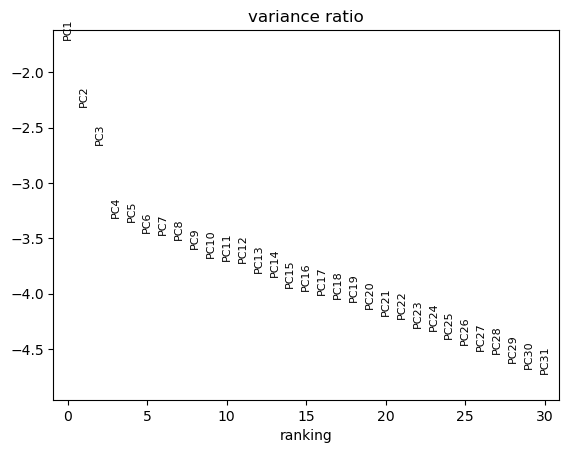

In [25]:
from __future__ import annotations
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import celltypist


# Load counts matrix (from alevin-fry)
count_matrix = sc.read_mtx("data/alevin_fry_quant/alevin/quants_mat.mtx")

# Create dummy cell names (no barcodes.tsv)
count_matrix.obs_names = [f"cell_{i}" for i in range(count_matrix.n_obs)]
count_matrix.obs_names_make_unique()

# Convert sparse matrix to dense (CellTypist may fail on sparse)
if hasattr(count_matrix.X, "A"):
    count_matrix.X = count_matrix.X.A

# Load transcript-to-gene mapping from splici 3col file
tx2gene_file = glob.glob("data/splici_output/*3col.tsv")[0]
tx2gene = pd.read_csv(tx2gene_file, sep="\t", header=None)
tx2gene.columns = ["transcript_id", "gene_id", "gene_name_placeholder"]

# Load gene ID → gene symbol mapping (required by CellTypist)
gene_map_file = "data/splici_output/gene_id_to_name.tsv"
gene_map = pd.read_csv(gene_map_file, sep="\t", header=None)
gene_map.columns = ["gene_id", "gene_symbol"]
id_to_name = dict(zip(gene_map.gene_id, gene_map.gene_symbol))

# Subset the tx2gene file to only transcripts actually detected
tx_detected = tx2gene.iloc[:count_matrix.shape[1]]
count_matrix.var_names = [id_to_name.get(g, g) for g in tx_detected["gene_id"]]
count_matrix.var_names_make_unique()


# Aggregate transcripts to genes
unique_genes = np.unique(count_matrix.var_names)
agg_X = np.zeros((count_matrix.n_obs, len(unique_genes)))

for i, gene in enumerate(unique_genes):
    idxs = [j for j, x in enumerate(count_matrix.var_names) if x == gene]
    agg_X[:, i] = count_matrix.X[:, idxs].sum(axis=1)

count_matrix_agg = sc.AnnData(X=agg_X)
count_matrix_agg.obs_names = count_matrix.obs_names
count_matrix_agg.var_names = unique_genes

# Normalize & log-transform for CellTypist

sc.pp.normalize_total(count_matrix_agg, target_sum=1e4)
sc.pp.log1p(count_matrix_agg)


#  PCA visualization, we want the n pcs that explain 95% of variation. This nummber was abritrarily chosen.
sc.tl.pca(count_matrix_agg)
var_ratio = count_matrix_agg.uns['pca']['variance_ratio']
cum_var = var_ratio.cumsum()
n_pcs_for_95_var = (cum_var >= 0.95).argmax() + 1 
print(f"Number of PCs to explain 95% variance: {n_pcs_for_95_var}")
sc.pl.pca_variance_ratio(count_matrix_agg, log=True)




Note that in our pca plot there is a significant drop/ an "elbow" around  PC2, indicating that PC1 captures a lot of the variance in the data. However, since we have so few cells and genes, I have decided to just use the first n PCs that explain 95% of the variance, which ends up being 38 PCs.

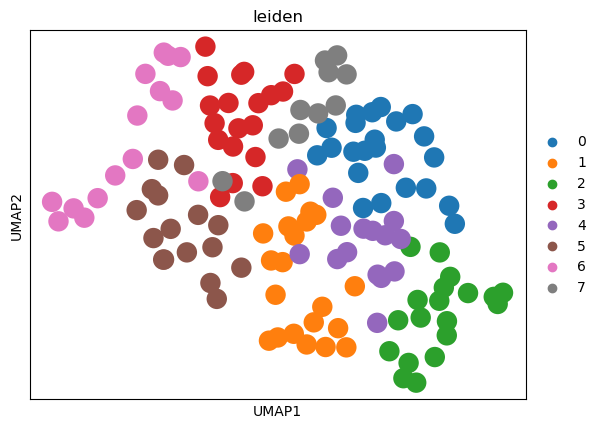

In [13]:
sc.pp.neighbors(count_matrix, n_neighbors=5, n_pcs=n_pcs_for_95_var)
sc.tl.leiden(count_matrix, resolution=1)
sc.tl.umap(count_matrix)
sc.pl.umap(count_matrix, color= "leiden")

# Annotation


For annotation purposes it would be beneficial to know what type of cells we are expecting. I.e. If we're interested in cancer cells from a biopsy within the mmouth a model for immune cells in the mouth could be chosen. For now we will use a general in-development human organ classifier model from CellTypist. For the annotation I used only the subsetted amount of genes and used leiden clustering to group similar cells together prior to annotation. Because of this there are less clusters than previously seen.


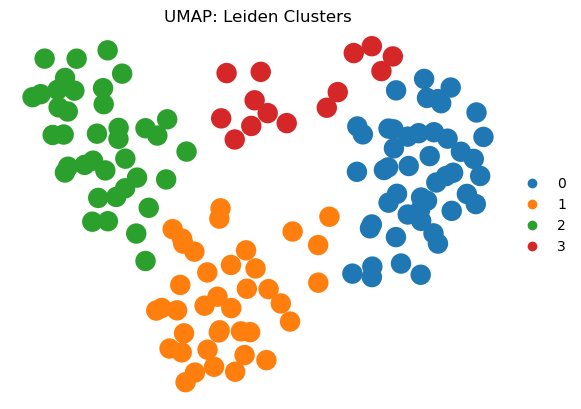

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 139 cells and 3 genes
🔗 Matching reference genes in the model
🧬 3 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


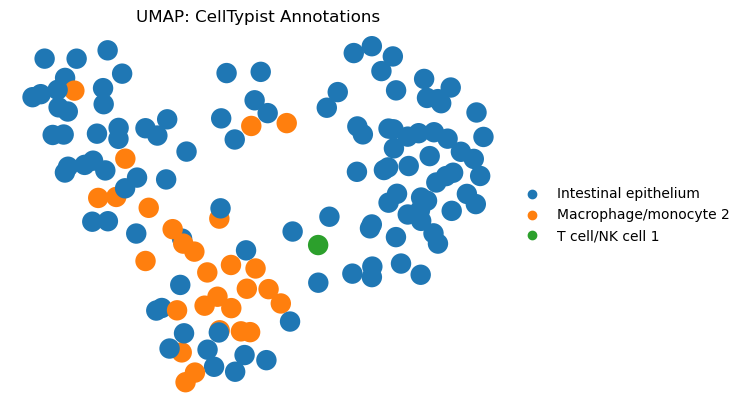

In [26]:


# Load counts matrix from alevin-fry
count_matrix = sc.read_mtx("data/alevin_fry_quant/alevin/quants_mat.mtx")
count_matrix.obs_names = [f"cell_{i}" for i in range(count_matrix.n_obs)]
count_matrix.obs_names_make_unique()

if hasattr(count_matrix.X, "A"):
    count_matrix.X = count_matrix.X.A

# Map transcript IDs to gene symbols
tx2gene_file = glob.glob("data/splici_output/*3col.tsv")[0]
tx2gene = pd.read_csv(tx2gene_file, sep="\t", header=None)
tx2gene.columns = ["transcript_id", "gene_id", "gene_name_placeholder"]

gene_map_file = "data/splici_output/gene_id_to_name.tsv"
gene_map = pd.read_csv(gene_map_file, sep="\t", header=None)
gene_map.columns = ["gene_id", "gene_symbol"]
id_to_name = dict(zip(gene_map.gene_id, gene_map.gene_symbol))

tx_detected = tx2gene.iloc[:count_matrix.shape[1]]
count_matrix.var_names = [id_to_name.get(g, g) for g in tx_detected["gene_id"]]
count_matrix.var_names_make_unique()

# Aggregate transcripts to genes
unique_genes = np.unique(count_matrix.var_names)
agg_X = np.zeros((count_matrix.n_obs, len(unique_genes)))

for i, gene in enumerate(unique_genes):
    idxs = [j for j, x in enumerate(count_matrix.var_names) if x == gene]
    agg_X[:, i] = count_matrix.X[:, idxs].sum(axis=1)

adata_all = sc.AnnData(X=agg_X)
adata_all.obs_names = count_matrix.obs_names
adata_all.var_names = unique_genes

# Normalize and log-transform
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)

# PCA and neighbors
sc.tl.pca(adata_all)
sc.pp.neighbors(adata_all, n_pcs=30)

# Leiden clustering
sc.tl.leiden(adata_all, resolution=1)

# UMAP before annotation (Leiden clusters)
sc.tl.umap(adata_all)
sc.pl.umap(
    adata_all,
    color='leiden',
    legend_loc='right margin',
    frameon=False,
    title="UMAP: Leiden Clusters"
)

# Subset genes for CellTypist
dev_human_organs_model = celltypist.models.Model.load("Developing_Human_Organs.pkl")
model_genes = set(dev_human_organs_model.classifier.features)
genes_in_model = [g for g in adata_all.var_names if g in model_genes]
adata_ct = adata_all[:, genes_in_model].copy()

# Run CellTypist
predictions = celltypist.annotate(
    adata_ct,
    model=dev_human_organs_model,
    majority_voting=True
)

# Add CellTypist predicted labels to AnnData
if hasattr(predictions.predicted_labels, "columns"):
    adata_all.obs['cell_type'] = predictions.predicted_labels.iloc[:,0].values
else:
    adata_all.obs['cell_type'] = predictions.predicted_labels.values

# UMAP colored by CellTypist annotations
sc.pl.umap(
    adata_all,
    color='cell_type',
    legend_loc='right margin',
    frameon=False,
    title="UMAP: CellTypist Annotations"
)
